## 문제: 1차 상미분 방정식 풀기 (Forward Euler, RK4 방법 적용하여 비교)

위에서 Forward Euler 방법으로 풀었던 다음 1차 상미분 방정식(ODE)을 이번에는 RK4(Runge-Kutta 4th order) 방법을 사용하여 $t=0$ 부터 $t=10$ 까지의 시간 범위에서 $y(t)$ 값을 예측하는 코드를 PyTorch로 작성합니다.

$$\frac{dy}{dt} = -0.5y$$

초기 조건 $y(0) = 1$, 최종 시간 $t_{end} = 10$, 시간 간격 $\Delta t = 0.1$, 초기 조건 $y(0) = 1$, 상수 $k = 0.5$ 입니다.

**해석적 해:**
이 ODE의 해석적 해는 $y(t) = e^{-0.5t}$ 입니다. RK4 방법으로 얻은 결과와 비교해보세요.

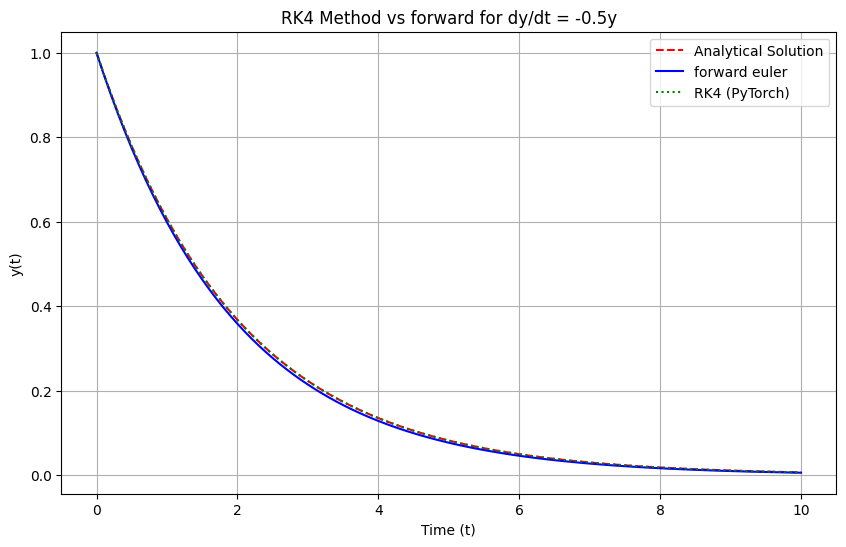

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. ODE 함수 정의: dy/dt = -k * y
def ode_function(t, y, k):
    return -k * y

# 2. 파라미터 설정
k = 0.5
y0 = torch.tensor(1.0)  # 초기 조건
t0 = 0.0
t_end = 10.0
dt = 0.1  # 시간 간격 (문제 명시된 값으로 설정)

# 시간 스텝 수 계산
num_steps = int((t_end - t0) / dt)

# 결과를 저장할 리스트 초기화
t_values = [t0]

y_rk4 = [y0.item()] #rk_4에 의한 추정 y
y_fw = [y0.item()]  #forward euler에 의한 추정 y

# RK4, forward 방법 구현
y_current_rk = y0
y_current_fw = y0
t_current = t0

for i in range(num_steps):
    # RK4 스텝 계산
    k1 = ode_function(t_current, y_current_rk, k)
    k2 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k1*dt, k)
    k3 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k2*dt, k)
    k4 = ode_function( t_current + dt, y_current_rk + k3*dt, k)

    # 다음 y_next_rk 값 업데이트
    y_next_rk = y_current_rk + dt*((k1 + 2*k2 + 2*k3 + k4) / 6)

    # 다음 y_next_fw 값 업데이트
    y_next_fw = y_current_fw + ode_function(t_current, y_current_fw, k)*dt


    # 시간 업데이트
    t_next = t_current + dt

    # 결과 저장
    t_values.append(t_next)
    y_rk4.append(y_next_rk.item())
    y_fw.append(y_next_fw.item())

    # 다음 스텝을 위해 값 업데이트
    y_current_rk = y_next_rk
    y_current_fw = y_next_fw
    t_current = t_next

# 3. 결과 시각화

# 해석적 해 계산
t_analytical = np.linspace(t0, t_end, 101)
y_analytical = np.exp(-k * t_analytical)

# plt.figure(figsize=(10, 6))
# plt.plot(t_analytical, y_analytical, label='Analytical Solution', color='red', linestyle='--')
# plt.plot(t_values, y_fw, label = 'forward euler', color = 'blue', linewidth = 1.5)
# plt.plot(t_values, y_rk4, label='RK4 (PyTorch)', color='green', linewidth = 1.5, linestyle=':')


# plt.title('RK4 Method vs forward for dy/dt = -0.5y')
# plt.xlabel('Time (t)')
# plt.ylabel('y(t)')
# plt.legend()
# plt.grid(True)
# plt.show()

/tmp/ipykernel_1183/4167667185.py:84: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1183/4167667185.py:84: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1183/4167667185.py:84: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1183/4167667185.py:84: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1183/4167667185.py:84: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1183/4167667185.py:84: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1183/4167667185.py:84: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

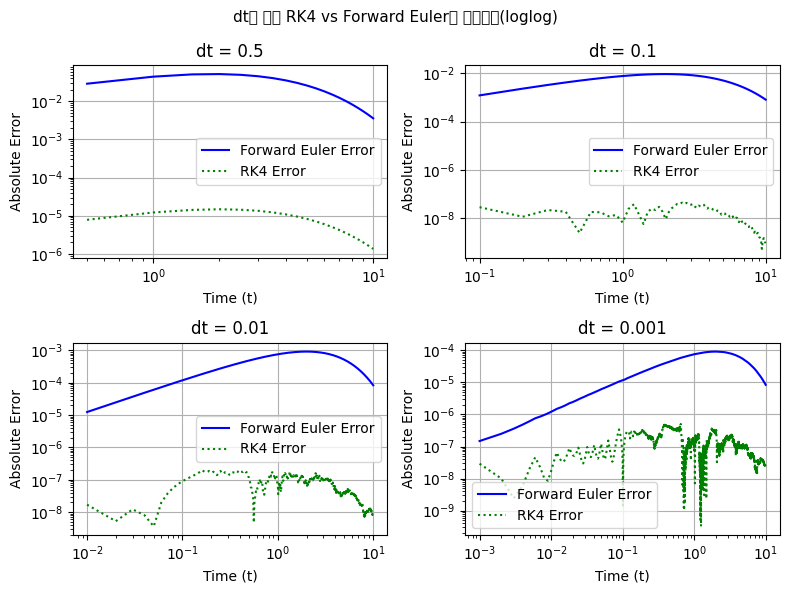

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. ODE 함수 정의: dy/dt = -k * y
def ode_function(t, y, k):
    return -k * y

# 2. 파라미터 설정
k = 0.5
y0 = torch.tensor(1.0) #초기 조건
t0 = 0.0
t_end = 10.0

dt_list = [0.5, 0.1, 0.01, 0.001] #시간 간격 여러개로

# 3. dt별 error 결과 저장 목적의 딕셔너리
results = {}  # {dt: (t_analytical, error_rk4, error_fw)}

for dt in dt_list:
    # 시간 스텝 수 계산
    num_steps = int((t_end - t0) / dt)

    # 결과 저장할 리스트 초기화
    t_values = [t0]
    y_rk4 = [y0.item()] #rk_4에 의한 추정y
    y_fw  = [y0.item()] #fw에 의한 추정y

    #사용할 변수 초기화
    y_current_rk = y0
    y_current_fw = y0
    t_current = t0

    for i in range(num_steps):
        #rk4 스텝 계산
        k1 = ode_function(t_current, y_current_rk, k)
        k2 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k1*dt, k)
        k3 = ode_function(t_current + 0.5 * dt, y_current_rk + 0.5 * k2*dt, k)
        k4 = ode_function(t_current + dt, y_current_rk + k3*dt, k)

        # 다음 y_next_rk 값 업데이트
        y_next_rk = y_current_rk + dt*((k1 + 2*k2 + 2*k3 + k4) / 6)
        # 다음 y_next_fw 값 업데이트
        y_next_fw = y_current_fw + ode_function(t_current, y_current_fw, k)*dt
        # 시간 업데이트
        t_next = t_current + dt

        #결과 저장
        t_values.append(t_next)
        y_rk4.append(y_next_rk.item())
        y_fw.append(y_next_fw.item())
        #다음 스텝을 위해 값 업데이트
        y_current_rk = y_next_rk
        y_current_fw = y_next_fw
        t_current = t_next

    #답지 생성
    t_analytical = np.linspace(t0, t_end, num_steps+1)
    y_analytical = np.exp(-k * t_analytical)

    error_rk4  = np.abs(np.array(y_rk4) - y_analytical)
    error_fw   = np.abs(np.array(y_fw)  - y_analytical)

    results[dt] = (t_analytical, error_rk4, error_fw)

# 4. subplot 시각화
fig, axes = plt.subplots(2, 2, figsize=(8, 6))  #axes = [[ax1, ax2], [ax3, ax4]]
axes = axes.flatten() #axes = [ax1, ax2, ax3, ax4]

for idx, dt in enumerate(dt_list):
    t_analytical, error_rk4, error_fw = results[dt]
    mask = t_analytical > 0

    axes[idx].loglog(t_analytical[mask], error_fw[mask],  label='Forward Euler Error', color='blue',  linewidth=1.5)
    axes[idx].loglog(t_analytical[mask], error_rk4[mask], label='RK4 Error',           color='green', linewidth=1.5, linestyle=':')

    axes[idx].set_title(f'dt = {dt}')
    axes[idx].set_xlabel('Time (t)')
    axes[idx].set_ylabel('Absolute Error')
    axes[idx].legend()
    axes[idx].grid(True)

fig.suptitle('dt에 따른 RK4 vs Forward Euler의 오차비교(loglog)', fontsize=11)
plt.tight_layout()
plt.show()